In [44]:
import torch 
from torch.utils.data import Dataset, DataLoader
from pyteomics import mgf
import numpy as np
import logging
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch import optim
import networkx as nx
from collections import deque
from matplotlib import pyplot as plt

from sklearn.metrics import (
    adjusted_mutual_info_score as AMI,
    adjusted_rand_score as ARI,
)
import random
import pandas as pd



<!-- # model input data preparation -->

In [45]:
processed_features = pd.read_hdf("./peptdeepwork/processed_features.h5", key="features")
processed_features


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
18080635323514663207,-0.066837,1.242110,0.746972,-0.069704,-0.069538,-0.069381,-0.069236,-0.068794,-0.068469,-0.067082,...,-0.172200,2.558338,-0.627303,0.411093,-0.575519,-0.451568,0.0,1.414214,-0.707107,-0.707107
14669807044004538680,-0.066838,-0.170780,0.725590,-0.069411,-0.069283,-0.069105,-0.069019,-0.068531,-0.068232,-0.066787,...,2.475728,0.805907,2.464574,0.843902,2.549063,1.464245,0.0,1.414214,-0.707107,-0.707107
584780176198780664,-0.068232,-0.312673,-0.937530,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068841,-0.067493,...,-0.630078,2.273397,0.485894,-0.611832,-0.575519,-0.451568,0.0,-0.707107,-0.707107,1.414214
584780176198780663,-0.067843,-0.312673,-0.633082,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068701,-0.067345,...,-0.630078,0.393660,-0.627303,-0.570494,-0.575519,-0.451568,0.0,-0.707107,1.414214,-0.707107
584780176198780662,-0.067066,-0.312673,0.364587,-0.069723,-0.069717,-0.069561,-0.069465,-0.068970,-0.068701,-0.067233,...,0.254574,-0.630680,-0.627303,-0.088796,-0.392081,-0.451568,0.0,1.414214,-0.707107,-0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,-0.066274,1.248301,0.661997,-0.069714,-0.069602,-0.069369,-0.069210,-0.068717,-0.068419,-0.066961,...,-0.331678,-0.522545,-0.440432,1.165769,1.806516,1.052303,0.0,-0.707107,-0.707107,1.414214
16568467721864459869,-0.063709,1.233154,2.434768,-0.067235,-0.067186,-0.067747,-0.067718,-0.067297,-0.067027,-0.065604,...,-0.630078,-0.630680,-0.627303,0.240429,2.568486,-0.451568,0.0,1.414214,-0.707107,-0.707107
16568467721864459870,-0.065605,1.233154,1.378530,-0.067235,-0.067186,-0.067642,-0.067580,-0.067176,-0.066908,-0.065476,...,-0.630078,-0.630680,-0.627303,2.642928,0.706135,-0.451568,0.0,-0.707107,1.414214,-0.707107
17256412178792009832,-0.063746,0.607052,2.259991,-0.067126,-0.067182,-0.067089,-0.067027,-0.066736,-0.066571,-0.065088,...,2.441639,2.558338,2.448579,2.565412,2.497366,3.718322,0.0,1.414214,-0.707107,-0.707107


In [46]:

from sklearn.preprocessing import MinMaxScaler


# Apply Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(processed_features)

# Convert back to DataFrame if needed
normalized_df = pd.DataFrame(normalized_data, columns=processed_features.columns)
normalized_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.000114,0.911099,0.492208,0.000070,0.000072,0.000067,0.000068,0.000065,0.000065,0.000060,...,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000,0.0,1.0,0.0,0.0
1,0.000114,0.461883,0.488509,0.000090,0.000090,0.000086,0.000083,0.000083,0.000081,0.000079,...,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014,0.0,1.0,0.0,0.0
2,0.000041,0.416769,0.200823,0.000064,0.000060,0.000054,0.000050,0.000045,0.000039,0.000033,...,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
3,0.000061,0.416769,0.253486,0.000064,0.000060,0.000054,0.000050,0.000045,0.000049,0.000043,...,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000,0.0,0.0,1.0,0.0
4,0.000102,0.416769,0.426063,0.000068,0.000060,0.000055,0.000052,0.000053,0.000049,0.000050,...,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641908,0.000143,0.913068,0.477509,0.000069,0.000068,0.000068,0.000070,0.000070,0.000068,0.000068,...,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036,0.0,0.0,0.0,1.0
641909,0.000277,0.908251,0.784163,0.000240,0.000235,0.000180,0.000173,0.000167,0.000162,0.000155,...,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000,0.0,1.0,0.0,0.0
641910,0.000178,0.908251,0.601455,0.000240,0.000235,0.000187,0.000182,0.000175,0.000170,0.000163,...,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000,0.0,0.0,1.0,0.0
641911,0.000275,0.709188,0.753930,0.000248,0.000235,0.000225,0.000220,0.000205,0.000193,0.000188,...,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660,0.0,1.0,0.0,0.0


<!-- Get a sample of the normalized data -->

In [47]:
normalized_df = normalized_df.dropna()  # Remove rows with NaN values
normalized_df.shape

(594273, 57)

In [48]:
def generate_random_samples(df, sample_size):
    # Shuffle the full DataFrame
    shuffled_df =  df.sample(frac=1)
    

    # Split into chunks of sample_size
    for i in range(0, len(shuffled_df), sample_size):
        yield shuffled_df.iloc[i:i + sample_size]



<!-- ## Ploting 3d  -->

In [49]:
def plot_tsne_results(tsne_df, size_multiplier=10, figsize=(12, 8)):
    """
    Visualizes t-SNE results with cluster coloring support and automatic dimensionality handling.
    
    Args:
        tsne_df (pd.DataFrame): DataFrame containing t-SNE coordinates (columns TSNE1, TSNE2...)
        size_multiplier (float): Scaling factor for 4th dimension visualization
        figsize (tuple): Figure size dimensions
    
    Returns:
        matplotlib.figure.Figure: The generated figure object
    """
    # Validate input columns
    tsne_cols = [col for col in tsne_df.columns if col.startswith('TSNE')]
    if not tsne_cols:
        raise ValueError("DataFrame must contain TSNE1, TSNE2... columns")
    n_components = len(tsne_cols)
    if n_components not in [2, 3, 4]:
        raise ValueError("Only 2D, 3D, or 4D t-SNE projections are supported")

    # Configure plot settings
    fig = plt.figure(figsize=figsize)
    color_by_cluster = 'cluster' in tsne_df.columns
    cmap = 'viridis' if color_by_cluster else None
    colors = tsne_df['cluster'] if color_by_cluster else None
    
    # Create appropriate axis
    if n_components >= 3:
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.gca()

    # Get data for plotting
    xs = tsne_df['TSNE1']
    ys = tsne_df['TSNE2']
    zs = tsne_df['TSNE3'] if n_components >= 3 else None
    
    
    # Additional parameters
    kwargs = {'alpha': 0.7}
    if colors is not None:
        kwargs['c'] = colors
        kwargs['cmap'] = cmap
    
    if n_components == 4:
        # Normalize and scale TSNE4 for point sizes
        sizes = (tsne_df['TSNE4'] - tsne_df['TSNE4'].min() + 0.2) * size_multiplier # here threshold of 0.2 is added to avoid zero size
        kwargs['s'] = sizes
    
    # Create scatter plot based on dimensions
    if n_components >= 3:
        sc = ax.scatter(xs, ys, zs, **kwargs)
    else:
        sc = ax.scatter(xs, ys, **kwargs)

    # Add labels and decorations
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    if n_components >= 3:
        ax.set_zlabel('TSNE3')
    
    title = f"{n_components}D t-SNE Projection"
    if color_by_cluster:
        title += " (Colored by Cluster)"
    if n_components == 4:
        title += " (Size = TSNE4)"
    plt.title(title)

    # Add colorbar if using clusters
    if color_by_cluster:
        plt.colorbar(sc, label='Cluster', ax=ax)
    
    # Add legend for size if using 4D
    if n_components == 4:
        size_info = f"Size scale: {size_multiplier}x normalized TSNE4"
        plt.legend(*sc.legend_elements(prop='sizes'), title=size_info)

    plt.grid(True)
    return fig


<!-- to find similar vectors need to reduce the dimensions using tsne -->


In [50]:
sample_size = 10000
sample_df = next(generate_random_samples(normalized_df, sample_size))
sample_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
308364,0.000055,0.222631,0.278428,0.000029,0.000032,0.000027,0.000026,0.000027,0.000022,0.000022,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0
629412,0.000178,0.914465,0.565950,0.000192,0.000186,0.000181,0.000172,0.000165,0.000158,0.000096,...,0.206573,0.348620,0.343589,0.025404,0.002840,0.000000,0.0,0.0,1.0,0.0
590775,0.000175,0.912220,0.527614,0.000161,0.000158,0.000151,0.000093,0.000074,0.000074,0.000072,...,0.042736,1.000000,0.002358,0.147157,0.120334,0.122618,0.0,0.0,1.0,0.0
581312,0.000101,0.916340,0.411124,0.000116,0.000111,0.000073,0.000064,0.000059,0.000059,0.000057,...,1.000000,0.334534,0.060150,0.063561,0.103768,0.127390,0.0,0.0,0.0,1.0
18554,0.000044,0.187301,0.222037,0.000056,0.000047,0.000045,0.000044,0.000044,0.000041,0.000039,...,0.000000,0.163123,0.217170,0.144691,0.000000,0.000000,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19576,0.000117,0.703954,0.501942,0.000090,0.000083,0.000080,0.000074,0.000067,0.000058,0.000054,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0
31003,0.000066,0.594957,0.288962,0.000053,0.000052,0.000052,0.000049,0.000049,0.000046,0.000044,...,0.052197,0.039301,0.000000,0.015446,0.000000,0.000385,0.0,0.0,1.0,0.0
390429,0.000155,0.287813,0.540449,0.000130,0.000126,0.000118,0.000112,0.000107,0.000106,0.000098,...,0.000000,0.000188,0.000000,0.000189,0.000188,0.000188,0.0,1.0,0.0,0.0
245449,0.000085,0.043691,0.370150,0.000058,0.000059,0.000050,0.000041,0.000032,0.000026,0.000026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=4, 
    method='exact',
    learning_rate='auto',
    random_state=43, 
    perplexity=30,  #perplexity must be less than n_samples
    n_iter=1000,
    )
tsneResult = tsne.fit_transform(sample_df)
tsne_result=pd.DataFrame(tsneResult,columns=['TSNE1','TSNE2','TSNE3',"TSNE4"])

In [ ]:
tsne_plot_df = tsne_result  # Add cluster column if exists
plot_tsne_results(tsne_plot_df, size_multiplier=1)
plt.show()

In [51]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_and_similarity(row1, row2, similarity_threshold=0.1):
    """
    Reduces two rows to 2D using t-SNE, plots them, and calculates their similarity.
    
    Args:
        row1 (list): First row of data.
        row2 (list): Second row of data.
        similarity_threshold (float): Threshold for determining similarity.

    Returns:
        dict: A dictionary containing reduced coordinates, distance, and similarity status.
    """
    # Combine the two rows into a single dataset
    data = np.array([row1, row2])

    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, method='exact', random_state=42, perplexity=1)
    reduced_data = tsne.fit_transform(data)

    # Plot the two points with different colors
    plt.figure(figsize=(6, 6))
    plt.scatter(reduced_data[0, 0], reduced_data[0, 1], color='blue', label='Row 1')
    plt.scatter(reduced_data[1, 0], reduced_data[1, 1], color='red', label='Row 2')
    plt.legend()
    plt.title('t-SNE Projection of Two Rows')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

    # Calculate Euclidean distance between the original rows
    distance = np.linalg.norm(np.array(row1) - np.array(row2))

    # Determine similarity based on the threshold
    similarity = 'Similar' if distance < similarity_threshold else 'Non-Similar'

    return {
        "reduced_coordinates": reduced_data,
        "distance": distance,
        "similarity": similarity
    }

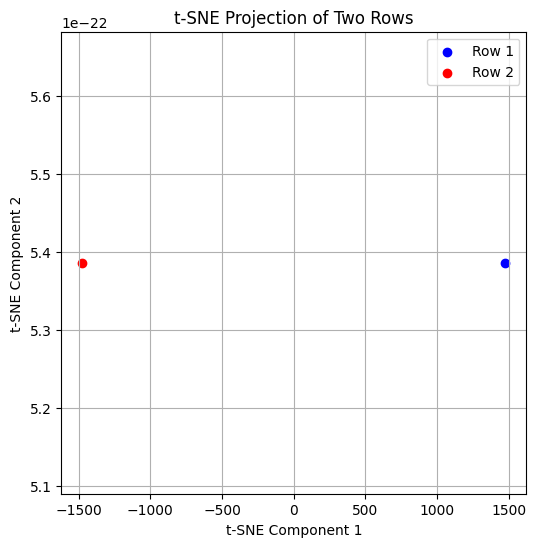

{'reduced_coordinates': array([[ 1.4735293e+03,  5.3859843e-22],
       [-1.4735293e+03,  5.3859843e-22]], dtype=float32), 'distance': 2.254567297280896, 'similarity': 'Non-Similar'}


In [52]:
row1 = sample_df.iloc[3] 
row2 = sample_df.iloc[2] 

result = tsne_and_similarity(row1, row2)
print(result)

<!-- Creating the DBScan -->


In [ ]:
class DBSCANBase:
    def __init__(self, eps, minPts):
        self._eps = eps
        self._minPts = minPts

    def fit(self, X):
        pass

    def score(self, X, y):
        y_pred = self.predict(X)
        return (AMI(y, y_pred), ARI(y, y_pred))

    def predict(self, X):
        pass

In [ ]:
class DBSCANGraphBased(DBSCANBase):
    
    def __init__(self, eps, minPts):
        super().__init__(eps, minPts)
    def fit(self, X):
        self._construct_graph(X)
        self._get_clusters()
        self._get_centroids(X)
        self._cluster_outliers(X)

    def predict(self, X):
        y = []
        for x in X:
            distances = {
                label: self._distance(x, centroid)
                for label, centroid in self._centroids.items()
            }
            y.append(min(distances, key=distances.get))
        return y

    def _construct_graph(self, X):
        cardinality = len(X)
        graph = nx.Graph()
        graph.add_nodes_from(
            list(range(cardinality)), is_core=False, visited=False, cluster=None
        )
        for i in range(cardinality):
            for j in range(i + 1, cardinality):
                if self._distance(X[i], X[j]) < self._eps:
                    graph.add_edge(i, j)
            if graph.degree[i] >= self._minPts:
                graph.nodes[i]["is_core"] = True
        self._graph = graph

    def _get_clusters(self):
        cluster_label = 0
        for node in self._graph:
            if not self._graph.nodes[node]["visited"] and self._graph.nodes[node][
                "is_core"
            ]:
                self._graph.nodes[node]["visited"] = True
                self._graph.nodes[node]["cluster"] = cluster_label
                self._bfs_node(node, cluster_label)
                cluster_label += 1
        self._num_clusters = cluster_label

    def _bfs_node(self, source, cluster_label):
        neighbors = self._graph.neighbors
        queue = deque([(source, len(self._graph), neighbors(source))])
        while queue:
            _, depth_now, children = queue[0]
            try:
                child = next(children)
                if not self._graph.nodes[child]["visited"]:
                    self._graph.nodes[child]["visited"] = True
                    self._graph.nodes[child]["cluster"] = cluster_label
                    if depth_now > 1:
                        queue.append((child, depth_now - 1, neighbors(child)))
            except StopIteration:
                queue.popleft()

    def _get_centroids(self, X):
        self._centroids = {}
        for i in range(self._num_clusters):
            X_list = []
            for node in self._graph:
                if self._graph.nodes[node]["cluster"] == i:
                    X_list.append(X[i])
            self._centroids.update({i: np.mean(X_list, axis=0)})

    def _cluster_outliers(self, X):
        for node in self._graph:
            if self._graph.nodes[node]["cluster"] is None:
                self._graph.nodes[node]["cluster"] = self.predict(X[node])

    @staticmethod
    def _distance(p1, p2):
        return np.linalg.norm(p1 - p2)


In [53]:
from sklearn.cluster import DBSCAN

def perform_dbscan_clustering(data, eps=1.3, min_samples=4):
    """
    Perform DBSCAN clustering on the given data.

    Args:
        data (pd.DataFrame): The input data to cluster.
        eps (float): Maximum distance between two samples for them to be considered as in the same neighborhood.
        min_samples (int): Minimum number of neighbors (including the point itself) for a point to be considered a core point.

    Returns:
        np.ndarray: Cluster labels for each point in the dataset.
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    cluster_labels = dbscan.fit_predict(data)
    return cluster_labels

# # Example usage
# cluster_labels = perform_dbscan_clustering(sample_df)
# cluster_labels

In [54]:
all_samples = []
cluster_offset = 0  # Start cluster labels from 0

for sample_df in generate_random_samples(normalized_df, sample_size):
    cluster_labels = perform_dbscan_clustering(sample_df)

    # Adjust cluster labels to be globally unique
    adjusted_labels = []
    for label in cluster_labels:
        if label == -1:
            adjusted_labels.append(-1)  # Keep noise label as -1
        else:
            adjusted_labels.append(label + cluster_offset)

    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"Number of clusters found: {num_clusters}")

    sample_df['cluster'] = adjusted_labels
    all_samples.append(sample_df)

    # Update offset for next iteration
    cluster_offset += num_clusters

# Combine all sample dataframes into one
final_df = pd.concat(all_samples, ignore_index=True)


Number of clusters found: 7
Number of clusters found: 9


C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 7


C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 7


...

C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 9


C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 9
Number of clusters found: 5


C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_21624\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


In [ ]:
# final_df

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,cluster
0,0.000098,0.628098,0.372757,0.000174,0.000148,0.000142,0.000137,0.000134,0.000131,0.000122,...,0.292711,0.191436,1.000000,0.012165,0.000000,0.0,0.0,0.0,1.0,0
1,0.000181,0.915212,0.683503,0.000128,0.000122,0.000109,0.000102,0.000095,0.000089,0.000081,...,0.000000,0.127551,0.000000,0.000000,0.275605,0.0,1.0,0.0,0.0,1
2,0.000131,0.757409,0.449322,0.000073,0.000073,0.000069,0.000069,0.000069,0.000070,0.000068,...,0.070579,0.037576,0.152331,0.295662,0.200799,0.0,0.0,0.0,1.0,0
3,0.000059,0.168161,0.276361,0.000111,0.000107,0.000099,0.000091,0.000084,0.000076,0.000070,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,0
4,0.000033,0.047355,0.167257,0.000059,0.000060,0.000051,0.000042,0.000034,0.000037,0.000029,...,0.014469,0.000000,0.008289,0.000000,0.000000,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594268,0.000039,0.433809,0.215240,0.000061,0.000057,0.000051,0.000043,0.000043,0.000041,0.000039,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,480
594269,0.000161,0.898297,0.583719,0.000131,0.000122,0.000111,0.000104,0.000101,0.000101,0.000091,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,481
594270,0.000120,0.921746,0.491815,0.000143,0.000139,0.000132,0.000123,0.000119,0.000113,0.000075,...,0.148565,0.405432,1.000000,0.234035,0.000000,0.0,0.0,1.0,0.0,482
594271,0.000088,0.851237,0.347304,0.000109,0.000105,0.000103,0.000099,0.000091,0.000090,0.000082,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,482


In [56]:
# Suppose the flag is a string: 'pearson', 'spearman', or 'kendall'
flag = 'spearman'  # you can change this dynamically

# Compute correlation
correlation_matrix = final_df.drop(columns=['cluster']).corr(method=flag)

print(correlation_matrix)


          0             1         2         3         4         5         6   \
0   1.000000  5.927011e-01  0.973257  0.799524  0.800090  0.815905  0.834516   
1   0.592701  1.000000e+00  0.581687  0.586979  0.569554  0.566643  0.568039   
2   0.973257  5.816866e-01  1.000000  0.745663  0.748909  0.766762  0.787062   
3   0.799524  5.869785e-01  0.745663  1.000000  0.987006  0.977031  0.966497   
4   0.800090  5.695543e-01  0.748909  0.987006  1.000000  0.989952  0.979796   
5   0.815905  5.666430e-01  0.766762  0.977031  0.989952  1.000000  0.990670   
6   0.834516  5.680394e-01  0.787062  0.966497  0.979796  0.990670  1.000000   
7   0.850193  5.728223e-01  0.803272  0.957094  0.968263  0.981783  0.990983   
8   0.863915  5.784320e-01  0.817053  0.947900  0.957627  0.970378  0.983004   
9   0.874196  5.857090e-01  0.826651  0.941826  0.949106  0.962092  0.973247   
10  0.881239  5.937520e-01  0.832670  0.937968  0.943610  0.955152  0.966743   
11  0.884726  6.018644e-01  0.834851  0.

<Axes: >

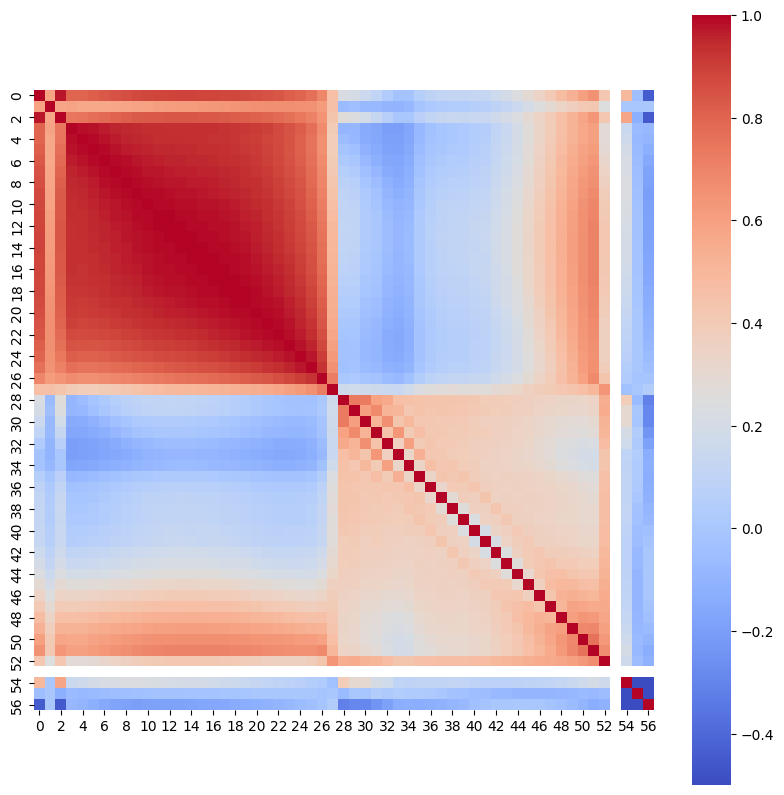

In [ ]:
# import seaborn as sns
# plt.figure(figsize=(10, 10))
# sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm', square=True)

In [55]:
final_df

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,cluster
0,0.000169,0.385445,0.506980,0.000155,0.000148,0.000140,0.000135,0.000129,0.000109,0.000100,...,0.097028,0.211328,0.107716,0.016044,0.009581,0.0,0.0,1.0,0.0,0
1,0.000059,0.546806,0.273324,0.000044,0.000044,0.000045,0.000043,0.000042,0.000044,0.000036,...,0.000000,0.208405,0.163224,0.000000,0.000000,0.0,0.0,1.0,0.0,0
2,0.000186,0.908115,0.657898,0.000142,0.000138,0.000131,0.000125,0.000118,0.000117,0.000112,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,1
3,0.000043,0.453764,0.251509,0.000047,0.000043,0.000041,0.000036,0.000038,0.000032,0.000032,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,0
4,0.000101,0.289938,0.446108,0.000075,0.000078,0.000073,0.000073,0.000065,0.000068,0.000062,...,0.981322,0.981276,0.432040,0.987841,0.429530,0.0,1.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594268,0.000028,0.339161,0.156279,0.000048,0.000051,0.000041,0.000037,0.000031,0.000031,0.000027,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,465
594269,0.000195,0.881220,0.653943,0.000108,0.000098,0.000092,0.000074,0.000071,0.000070,0.000068,...,0.152695,1.000000,0.018565,0.126663,0.000000,0.0,1.0,0.0,0.0,466
594270,0.000049,0.578467,0.248785,0.000078,0.000071,0.000065,0.000054,0.000044,0.000040,0.000032,...,0.193089,0.013689,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,465
594271,0.000045,0.648554,0.224656,0.000075,0.000069,0.000062,0.000051,0.000049,0.000047,0.000044,...,0.083638,0.114290,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,465


In [57]:

cluster_counts = pd.Series(final_df['cluster']).value_counts()
print(cluster_counts)
len(cluster_counts)


cluster
-1      14257
 113     3391
 359     3378
 455     3363
 325     3352
        ...  
 244        2
 121        2
 187        2
 251        2
 45         2
Name: count, Length: 470, dtype: int64


470

In [68]:
# sample_df_with_cluster_labels = sample_df.copy()
# sample_df_with_cluster_labels['cluster'] = cluster_labels
# sample_df_with_cluster_labels

In [60]:

# tsne_result_with_cluster_labels = tsne_result.copy()
# tsne_result_with_cluster_labels['cluster'] = cluster_labels
# tsne_result_with_cluster_labels

In [62]:

# plot_tsne_results(tsne_result_with_cluster_labels, size_multiplier=1)
# plt.show()

<!-- ## Creating Siamese Pairs  -->

<!-- creating siamese pairs and load with a data loader  -->

In [65]:
def calculate_cosine_similarity(vec1, vec2):
    """
    Calculate cosine similarity between two vectors.
    
    Args:
        vec1 (torch.Tensor): First vector.
        vec2 (torch.Tensor): Second vector.
    
    Returns:
        float: Cosine similarity value.
    """
    # Convert rows to tensors and add batch dimension if needed
    vec1 = torch.tensor(vec1.values, dtype=torch.float32)
    vec2 = torch.tensor(vec2.values, dtype=torch.float32)
    
    return F.cosine_similarity(vec1, vec2, dim=0).item()

In [70]:

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

def create_siamese_pairs(df, pairs_per_cluster=10, test_size=0.2):
    """
    Creates positive/negative pairs for Siamese network training from clustered data
    
    Args:
        df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
        pairs_per_cluster: Number of pairs to generate per cluster
        test_size: Proportion of data for validation
    
    Returns:
        (train_loader, val_loader): PyTorch DataLoader objects for training
    """
    # Validate input
    if 'cluster' not in df.columns:
        raise ValueError("DataFrame must contain 'cluster' column")
    
    features = df.drop('cluster', axis=1)
    clusters = df['cluster'].values
    unique_clusters = np.unique(clusters)
    
    # Storage for pairs and labels
    pairs = []
    labels = []
    similar_pairs = []
    dissimilar_pairs = []
    
    # Generate pairs for each cluster
    for cluster in unique_clusters:
        print(f"Processing cluster {cluster}...")
        # need to handle clusters of -1 (noise points in DBSCAN)
        if cluster == -1:
            continue
        # Get indices for current cluster
        cluster_indices = np.where(clusters == cluster)[0]
        
        # Skip clusters with < 2 samples
        if len(cluster_indices) < 2:
            continue
            
        # Positive pairs (same cluster)
        count = 0
        for i in range(pairs_per_cluster):
            count += 1
            if( count % 10 == 1):
                print(f"Processed {count} pairs for cluster {cluster}...")    
            
            # Randomly select two different samples from cluster
            similar_try_count = 0
            while True:
                if similar_try_count > 300:
                    print("Too many tries to find a similar pair")
                    break
                similar_try_count += 1
                idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
                if cos_sim > 0.9:
                    print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
                    pairs.append([features.iloc[idx1], features.iloc[idx2]])
                    similar_pairs.append([idx1, idx2])
                    labels.append(0)
                    break
            
            # pairs.append([features[idx1], features[idx2]])
            # labels.append(0)
            
            # Negative pair (different cluster)
            dissimilar_try_count = 0
            while True:
                # Randomly select a sample from the different clusters
                if dissimilar_try_count > 300:
                    print("Too many tries to find a dissimilar pair")
                    break
                dissimilar_try_count += 1

                other_clusters = unique_clusters[unique_clusters != cluster]
                other_cluster = np.random.choice(other_clusters)
                other_indices = np.where(clusters == other_cluster)[0]
                idx3 = np.random.choice(other_indices)
                
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
                if cos_sim < 0.1:
                    print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
                    pairs.append([features.iloc[idx1], features.iloc[idx3]])
                    dissimilar_pairs.append([idx1, idx3])
                    labels.append(1)
                    break
                
            # other_clusters = unique_clusters[unique_clusters != cluster]
            # other_cluster = np.random.choice(other_clusters)
            # other_indices = np.where(clusters == other_cluster)[0]
            # idx3 = np.random.choice(other_indices)
            # pairs.append([features[idx1], features[idx3]])
            # labels.append(1)
    
    # Convert to arrays
    pairs = np.array(pairs)
    labels = np.array(labels)
    
    print(f"Total pairs: {len(pairs)}, Total labels: {len(labels)}")
    print(f"Similar pairs: {len(similar_pairs)}, Dissimilar pairs: {len(dissimilar_pairs)}")
    
    
    # Shuffle and split
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    pairs = pairs[indices]
    labels = labels[indices]
    
    # Split into train/validation
    X_train, X_val, y_train, y_val = train_test_split(
        pairs, labels, test_size=test_size, stratify=labels
    )
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    
    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)
    print("y_train shape:", y_train.shape)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=100)
    
    return train_loader, val_loader

# Usage example
# train_loader, val_loader = create_siamese_pairs(your_dataframe)



In [82]:
train_loader, val_loader = create_siamese_pairs(final_df)

Processing cluster -1...
Processing cluster 0...
Processed 1 pairs for cluster 0...
idx1: 3447, idx2: 8363, cos_sim: 0.9659315943717957
idx1: 3447, idx3: 551356, cos_sim: 0.08839565515518188
idx1: 8744, idx2: 7785, cos_sim: 0.9281728267669678
idx1: 8744, idx3: 430325, cos_sim: 0.03144829720258713
idx1: 1715, idx2: 8778, cos_sim: 0.9394071698188782
idx1: 1715, idx3: 49251, cos_sim: 0.05888129025697708
idx1: 3068, idx2: 2858, cos_sim: 0.902765154838562
idx1: 3068, idx3: 464823, cos_sim: 0.09217540919780731
idx1: 3255, idx2: 3529, cos_sim: 0.9652360677719116
idx1: 3255, idx3: 275735, cos_sim: 0.0738939419388771
idx1: 1413, idx2: 1111, cos_sim: 0.9708946943283081
idx1: 1413, idx3: 305133, cos_sim: 0.06721998006105423
idx1: 9605, idx2: 2839, cos_sim: 0.9691029787063599
idx1: 9605, idx3: 360336, cos_sim: 0.042063429951667786
idx1: 2753, idx2: 6948, cos_sim: 0.9656516909599304
idx1: 2753, idx3: 371633, cos_sim: 0.06644467264413834
idx1: 5454, idx2: 3135, cos_sim: 0.9075498580932617
idx1: 5454

<!-- verify siamese pair -->


In [ ]:

# from sklearn.model_selection import train_test_split
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, TensorDataset

# def create_siamese_pairs_temp(df, pairs_per_cluster=1000, test_size=0.2):
#     """
#     Creates positive/negative pairs for Siamese network training from clustered data
    
#     Args:
#         df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
#         pairs_per_cluster: Number of pairs to generate per cluster
#         test_size: Proportion of data for validation
    
#     Returns:
#         (train_loader, val_loader): PyTorch DataLoader objects for training
#     """
#     # Validate input
#     if 'cluster' not in df.columns:
#         raise ValueError("DataFrame must contain 'cluster' column")
    
#     features = df.drop('cluster', axis=1)
#     clusters = df['cluster'].values
#     unique_clusters = np.unique(clusters)
    
#     # Storage for pairs and labels
#     similarPairsIndices = []
#     dissimilarPairsIndices = []
#     pairs = []
#     labels = []
    
#     # Generate pairs for each cluster
#     for cluster in unique_clusters:
#         print(f"Processing cluster {cluster}...")
#         if cluster == -1:
#             continue
#         # Get indices for current cluster
#         cluster_indices = np.where(clusters == cluster)[0]
        
#         # Skip clusters with < 2 samples
#         if len(cluster_indices) < 2:
#             continue
            
#         # Positive pairs (same cluster)
#         count = 0 
#         for i in range(pairs_per_cluster):
#             if(count % 10 ==0):
#                 count += 1
#                 print(f"Processing cluster {cluster}...{count}")
#             # Randomly select two different samples from cluster
#             similar_try_count = 0
#             while True:
#                 if similar_try_count > 300:
#                     print("Too many tries to find a similar pair")
#                     break
#                 similar_try_count += 1
#                 idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
#                 if cos_sim > 0.9:
#                     print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx2]])
#                     similarPairsIndices.append([idx1, idx2])
#                     labels.append(0)
#                     break
            
#             # idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#             # cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
            
            
#             # pairs.append([features.iloc[idx1], features.iloc[idx2]])
#             # similarPairsIndices.append([idx1, idx2])
#             # labels.append(0)
            
#             # Negative pair (different cluster)
            
#             dissimilar_try_count = 0
#             while True:
                
#                 if dissimilar_try_count > 300:
#                     print("Too many tries to find a dissimilar pair")
#                     break
#                 dissimilar_try_count += 1

#                 other_clusters = unique_clusters[unique_clusters != cluster]
#                 other_cluster = np.random.choice(other_clusters)
#                 other_indices = np.where(clusters == other_cluster)[0]
#                 idx3 = np.random.choice(other_indices)
                
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
#                 if cos_sim < 0.4:
#                     print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx3]])
#                     dissimilarPairsIndices.append([idx1, idx3])
#                     labels.append(1)
#                     break
                
#             # other_clusters = unique_clusters[unique_clusters != cluster]
#             # other_cluster = np.random.choice(other_clusters)
#             # other_indices = np.where(clusters == other_cluster)[0]
#             # idx3 = np.random.choice(other_indices)
            
            
#             # print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#             # pairs.append([features.iloc[idx1], features.iloc[idx3]])
#             # dissimilarPairsIndices.append([idx1, idx3])
#             # labels.append(1)
    
#     # Convert to arrays
#     pairs = np.array(pairs)
#     labels = np.array(labels)
    
#     # Shuffle and split
#     indices = np.arange(len(labels))
#     np.random.shuffle(indices)
#     pairs = pairs[indices]
#     labels = labels[indices]
    
#     return pairs, labels, similarPairsIndices, dissimilarPairsIndices
    
#     # # Split into train/validation
#     # X_train, X_val, y_train, y_val = train_test_split(
#     #     pairs, labels, test_size=test_size, stratify=labels
#     # )
    
#     # # Convert to PyTorch tensors
#     # X_train = torch.FloatTensor(X_train)
#     # X_val = torch.FloatTensor(X_val)
#     # y_train = torch.LongTensor(y_train)
#     # y_val = torch.LongTensor(y_val)
    
#     # # Create DataLoaders
#     # train_dataset = TensorDataset(X_train, y_train)
#     # val_dataset = TensorDataset(X_val, y_val)
    
#     # train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
#     # val_loader = DataLoader(val_dataset, batch_size=100)
    
#     # return train_loader, val_loader

# # Usage example
# # train_loader, val_loader = create_siamese_pairs(your_dataframe)


# pairs, labels, similar, dissimilar  = create_siamese_pairs_temp(sample_df_with_cluster_labels)

# len(similar) +len(dissimilar)
# len(similar) 
# len(dissimilar)

In [ ]:
# sample_df_with_cluster_labels.iloc[similar[1000]]

In [ ]:
# i = 2000
# plot_tsne_results(tsne_result_with_cluster_labels.iloc[similar[i]], size_multiplier=100)
# calculate_cosine_similarity(sample_df_with_cluster_labels.iloc[similar[i][0]], sample_df_with_cluster_labels.iloc[similar[i][1]])

<!-- # Loading the deconvoluted spectra using a dataloader -->

In [72]:
class SpectrumDataset(Dataset):
    def __init__(self,mgf_file_path, max_peaks=200):
        self.mgf_file_path = mgf_file_path
        self.max_peaks = max_peaks
        self.spectra = list(mgf.read(mgf_file_path))
        
    def __len__(self):
        return len(self.spectra)

    def __getitem__(self, index):
        spectrum = self.spectra[index]
        mz_values = spectrum.get("m/z array", np.array([]))
        intensity_values = spectrum.get("intensity array", np.array([]))
        
        # normalize intensities
        intensity_values = intensity_values / np.max(intensity_values) if intensity_values.size else intensity_values

        return torch.tensor(np.stack(mz_values,intensity_values), axis=1)

In [73]:
class SiamesNetwork(nn.Module):
    def __init__(self, input_dim=57):
        super(SiamesNetwork, self).__init__()
        
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,32),
            nn.SELU(),
            nn.Linear(32,50),
            nn.SELU()            
        )
        # self.cnn11 = nn.Sequential(
        #     nn.Conv1d(1,30,3),
        #     nn.SELU(),
        #     nn.MaxPool1d(2),
        #     nn.SELU()
        # )
        
        self.cnn21 = nn.Sequential(
            nn.Conv1d(1,30,3),
            nn.SELU(),
            nn.MaxPool1d(2),
            nn.SELU(),
            nn.Conv1d(30,30,3),
            nn.MaxPool1d(2),
            nn.SELU()
        )
        self.fc2 =nn.Linear(330,32)
    # (3000x11 and 25775x32)
    def forward_once(self, x):
        # Get feature embeddings
        x = self.fc1(x)
        # torch.Size([100, 50])
        
        x = x.unsqueeze(1)
        # ([100, 1, 50])
        x = self.cnn21(x)
        # [100, 30, 11]
        
        
        x = x.view(x.size(0), -1)
        output = self.fc2(x)
        
        # Compute Euclidean distance
        return output
    
    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)
        return output1, output2


In [128]:
# Define the Contrastive Loss Function
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # # Calculate the euclidian distance and calculate the contrastive loss
        # euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)

        # loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
        #                                 (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        # return loss_contrastive
        
        euclidean_distance = F.pairwise_distance(output1, output2)
        euclidean_distance = euclidean_distance.double()
        #print(euclidean_distance)
        label = label.double()
        loss_contrastive = torch.mean(label * euclidean_distance + (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))

        return loss_contrastive



In [76]:
# net =SiamesNetwork()
# lossFunc = ContrastiveLoss()
# optimzer = optim.Adam(net.parameters(), lr = 0.0005)
for batch_idx, (pairs, labels) in enumerate(train_loader):
    print(pairs.shape)
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(x1.shape)
    print(x1.size(0))
    x11 = x1.view(x1.size(0), -1)
    print(x11.shape)
    

    break

torch.Size([100, 2, 57])
torch.Size([100, 57])
100
torch.Size([100, 57])


In [129]:
if __name__ == "__main__":
    
    model = SiamesNetwork()
    criterion = ContrastiveLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        model.train()
        # # define the sample size and get a random sample
        # sample_size = 1000
        # sample_df = next(generate_random_samples(normalized_df, sample_size))
        # # perform DBSCAN clustering on the sample
        # cluster_labels = perform_dbscan_clustering(sample_df)
        # # add the cluster labels to the sample dataframe
        # sample_df['cluster'] = cluster_labels
        
        # we have already created data loaders for the final_df
        # train_loader, val_loader = create_siamese_pairs(final_df)  
        
        
        
        # train_loader, val_loader = create_siamese_pairs(final_df) is already defined above
        epoch_loss = 0.0
        for batch_idx, (pairs, labels) in enumerate(train_loader):
            print("Batch index:", batch_idx) if batch_idx % 79 == 0 else None
             # Split pairs into two inputs
            x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
            x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
                
            optimizer.zero_grad()
            output1, output2 = model(x1, x2)
            contrastive_loss = criterion(output1, output2, labels)
            contrastive_loss.backward()
            optimizer.step()
            epoch_loss += contrastive_loss.item()
            
            
            
        print(f"Epoch {epoch+1}, contrastive_loss: {epoch_loss/len(train_loader):.4f}")
    

Batch index: 0
Epoch 1, contrastive_loss: 0.4498
Batch index: 0
Epoch 2, contrastive_loss: 0.4025
Batch index: 0
Epoch 3, contrastive_loss: 0.3913
Batch index: 0
Epoch 4, contrastive_loss: 0.3783
Batch index: 0
Epoch 5, contrastive_loss: 0.3709
Batch index: 0
Epoch 6, contrastive_loss: 0.3651
Batch index: 0
Epoch 7, contrastive_loss: 0.3601
Batch index: 0
Epoch 8, contrastive_loss: 0.3551
Batch index: 0
Epoch 9, contrastive_loss: 0.3528
Batch index: 0
Epoch 10, contrastive_loss: 0.3490
Batch index: 0
Epoch 11, contrastive_loss: 0.3444
Batch index: 0
Epoch 12, contrastive_loss: 0.3438
Batch index: 0
Epoch 13, contrastive_loss: 0.3395
Batch index: 0
Epoch 14, contrastive_loss: 0.3357
Batch index: 0
Epoch 15, contrastive_loss: 0.3349
Batch index: 0
Epoch 16, contrastive_loss: 0.3379
Batch index: 0
Epoch 17, contrastive_loss: 0.3328
Batch index: 0
Epoch 18, contrastive_loss: 0.3315
Batch index: 0
Epoch 19, contrastive_loss: 0.3277
Batch index: 0
Epoch 20, contrastive_loss: 0.3231
Batch ind

In [154]:
import torch
import torch.nn.functional as F

def evaluate_model(model, test_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for pairs, labels in test_loader:
            x1 = pairs[:, 0, :]
            x2 = pairs[:, 1, :]

            output1, output2 = model(x1, x2)

            # Cosine similarity
            cos_sim = F.cosine_similarity(output1, output2)
            

            # Compute loss
            loss = criterion(output1, output2, labels)
            total_loss += loss.item()

            # Apply prediction logic
            predicted = torch.full_like(labels, -1.0)  # initialize with -1 (undecided)

            # predicted[cos_sim > 0.9] = 0  # predict similar
            predicted[cos_sim < 0.1] = 1  # predict dissimilar

            # Only count predictions that are decided (not -1)
            mask = predicted != -1
            # correct += (predicted[mask] == labels[mask]).sum().item()
            print(mask)
            correct += (predicted == labels).sum().item()
            total += mask.sum().item()

    accuracy = 100 * correct / total if total > 0 else 0.0
    avg_loss = total_loss / len(test_loader)

    print(f"Total pairs: {len(test_loader.dataset)}, Correct: {correct}, Total: {total}")
    print(f"Evaluation - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}% (on {total} confident predictions)")

# Example usage (assuming you have test_loader and model trained)
if __name__ == "__main__":
    evaluate_model(model, val_loader, criterion)


tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False,

In [159]:
for batch_idx, (pairs, labels) in enumerate(val_loader):
    model.eval()
    print("Batch index:", batch_idx) if batch_idx % 79 == 0 else None
     # Split pairs into two inputs
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(labels)
    output1, output2 = model(x1, x2)

    # Cosine similarity
    cos_sim = F.cosine_similarity(output1, output2)
    print("cos_sim:", cos_sim)  
    

    # Compute loss
    loss = criterion(output1, output2, labels)
    print(f"Loss: {loss.item()}")

    break
    
        

Batch index: 0
tensor([0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        1, 1, 1, 1])
cos_sim: tensor([0.9831, 0.9968, 0.9922, 0.9896, 0.9905, 0.9999, 0.9911, 0.9959, 0.9949,
        0.9832, 0.9958, 0.9888, 0.9989, 0.9976, 0.9777, 0.9999, 0.9986, 0.9954,
        0.9970, 0.9969, 0.9987, 0.9968, 0.9932, 0.9963, 0.9983, 0.9975, 0.9922,
        0.9859, 0.9943, 0.9833, 0.9927, 0.9992, 0.9959, 0.9903, 0.9823, 0.9777,
        0.9950, 0.9980, 0.9720, 0.9833, 0.9971, 0.9962, 0.9929, 0.9879, 0.9876,
        0.9939, 0.9983, 0.9979, 0.9987, 0.9976, 0.9927, 0.9987, 0.9971, 0.9923,
        0.9958, 0.9952, 0.9985, 0.9877, 0.9990, 0.9754, 0.9910, 0.9895, 0.9966,
        0.9982, 0.9977, 0.9699, 0.9971, 0.9995, 0.9770, 0.9998, 0.9918, 0.9